In [31]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_candidates = ['AppleGothic', 'NanumGothic', 'Malgun Gothic']
available_fonts = {font.name for font in fm.fontManager.ttflist}
font_name = next((font for font in font_candidates if font in available_fonts), 'DejaVu Sans')

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', palette='Set2', font=font_name)

print(f'사용 폰트: {font_name}')

사용 폰트: AppleGothic


In [32]:
import pandas as pd
from pathlib import Path

v1_candidates = [
    Path('data/user_behavior_50000/netflix_user_behavior_churn_50000.csv'),
    Path('../data/user_behavior_50000/netflix_user_behavior_churn_50000.csv'),
]
v2_candidates = [
    Path('data/user_behavior_50000/netflix_user_behavior_churn_50000v2.csv'),
    Path('../data/user_behavior_50000/netflix_user_behavior_churn_50000v2.csv'),
]

v1_path = next(path for path in v1_candidates if path.exists())
v2_path = next(path for path in v2_candidates if path.exists())

v1 = pd.read_csv(v1_path)
v2 = pd.read_csv(v2_path)

v1_path, v2_path


## 컬럼 설명

| 컬럼명 | 설명 |
| --- | --- |
| `user_id` | 사용자 고유 식별자 |
| `age` | 사용자 나이 |
| `gender` | 사용자 성별 |
| `region` | 사용자가 속한 지역 |
| `subscription_type` | 구독 요금제 유형 |
| `payment_method` | 결제 수단 |
| `primary_device` | 주로 사용하는 시청 기기 |
| `account_age_months` | 계정 생성 후 경과 개월 수 |
| `favorite_genre` | 사용자가 선호하는 장르 |
| `time_of_day` | 주로 이용하는 시간대 |
| `recommendation_source` | 추천 또는 유입 경로 |
| `session_count` | 집계 기간 내 접속 세션 수 |
| `avg_watch_time_minutes_per_week` | 주당 평균 시청 시간(분) |
| `watch_sessions_per_week` | 주당 시청 세션 수 |
| `completion_rate` | 콘텐츠 평균 완료율 |
| `avg_rating_given` | 사용자가 남긴 평균 평점 |
| `app_rating` | 앱에 대한 사용자 평가 점수 |
| `recommendation_click_rate` | 추천 콘텐츠 클릭률 |
| `days_since_last_login` | 마지막 로그인 이후 경과 일수 |
| `churned` | 이탈 여부 타겟값 (`1`: 이탈, `0`: 유지) |


In [33]:
v1.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   user_id                          50000 non-null  str  
 1   age                              50000 non-null  int64
 2   gender                           50000 non-null  str  
 3   region                           50000 non-null  str  
 4   subscription_type                50000 non-null  str  
 5   payment_method                   50000 non-null  str  
 6   primary_device                   50000 non-null  str  
 7   account_age_months               50000 non-null  int64
 8   favorite_genre                   50000 non-null  str  
 9   time_of_day                      50000 non-null  str  
 10  recommendation_source            50000 non-null  str  
 11  session_count                    50000 non-null  int64
 12  avg_watch_time_minutes_per_week  50000 non-null  int64
 1

## EDA

v1과 v2는 같은 구조의 데이터셋으로 보고, 이후 분석은 v1을 기준으로 진행한다.

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.3f}'.format)
font_name = plt.rcParams.get('font.family', ['AppleGothic'])[0]
sns.set_theme(style='whitegrid', palette='Set2', font=font_name)
plt.rcParams['axes.unicode_minus'] = False

df = v1.copy()

diff_by_col = (v1 != v2).sum()
version_check = pd.DataFrame({
    'same_shape': [v1.shape == v2.shape],
    'same_columns': [v1.columns.equals(v2.columns)],
    'same_user_id_order': [v1['user_id'].equals(v2['user_id'])],
    'changed_cells': [int(diff_by_col.sum())],
    'changed_columns': [', '.join(diff_by_col[diff_by_col > 0].index)],
})

version_check

,same_shape,same_columns,same_user_id_order,changed_cells,changed_columns
0,True,True,True,114,churned


In [35]:
column_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'unique': df.nunique(),
})

column_summary

,dtype,missing,unique
user_id,str,0,50000
age,int64,0,61
gender,str,0,2
region,str,0,6
subscription_type,str,0,3
payment_method,str,0,4
primary_device,str,0,4
account_age_months,int64,0,131
favorite_genre,str,0,7
time_of_day,str,0,4


### 타겟 분포

In [36]:
target_distribution = pd.concat(
    [
        df['churned'].value_counts(normalize=False).rename('count'),
        df['churned'].value_counts(normalize=True).rename('ratio'),
    ],
    axis=1,
).sort_index()

target_distribution

,count,ratio
churned,,
0,39500,0.790
1,10500,0.210


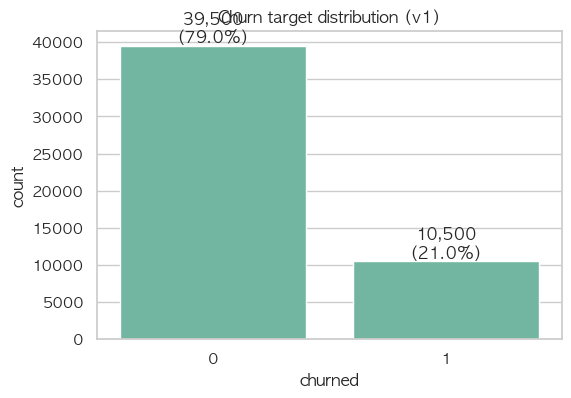

In [37]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='churned', ax=ax)
ax.set_title('Churn target distribution (v1)')
ax.set_xlabel('churned')
ax.set_ylabel('count')

total = len(df)
for container in ax.containers:
    ax.bar_label(container, labels=[f'{int(v.get_height()):,}\n({v.get_height() / total:.1%})' for v in container])

plt.show()

**해석**

- 전체 50,000명 중 유지 고객은 39,500명(79.0%), 이탈 고객은 10,500명(21.0%)이다.
- 타겟이 완전히 균형 잡힌 데이터는 아니지만, 이탈 클래스가 20% 이상이므로 극단적인 불균형 데이터는 아니다.
- 모델링 단계에서는 accuracy만 보면 유지 고객을 잘 맞히는 모델이 과대평가될 수 있으므로 recall, precision, F1, ROC-AUC, PR-AUC를 함께 확인하는 것이 좋다.

### 피처 분포

In [38]:
target_col = 'churned'
id_col = 'user_id'
numeric_cols = df.drop(columns=[id_col, target_col]).select_dtypes(include='number').columns.tolist()
categorical_cols = df.drop(columns=[id_col, target_col]).select_dtypes(exclude='number').columns.tolist()

numeric_cols, categorical_cols

(['age',
  'account_age_months',
  'session_count',
  'avg_watch_time_minutes_per_week',
  'watch_sessions_per_week',
  'completion_rate',
  'avg_rating_given',
  'app_rating',
  'recommendation_click_rate',
  'days_since_last_login'],
 ['gender',
  'region',
  'subscription_type',
  'payment_method',
  'primary_device',
  'favorite_genre',
  'time_of_day',
  'recommendation_source'])

In [39]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,"50,000.000",39.216,13.072,19.000,31.000,37.000,45.000,79.000
account_age_months,"50,000.000",44.803,21.890,1.000,29.000,45.000,60.000,135.000
session_count,"50,000.000",1.630,0.989,1.000,1.000,1.000,2.000,5.000
avg_watch_time_minutes_per_week,"50,000.000",277.951,157.605,15.000,165.000,240.000,349.000,820.000
watch_sessions_per_week,"50,000.000",5.731,3.467,1.000,3.000,5.000,7.000,19.000
completion_rate,"50,000.000",73.127,11.149,23.000,66.000,74.000,81.000,100.000
avg_rating_given,"50,000.000",3.845,0.612,2.000,3.000,4.000,4.000,5.000
app_rating,"50,000.000",3.946,0.639,2.000,4.000,4.000,4.000,5.000
recommendation_click_rate,"50,000.000",38.641,19.474,0.000,24.000,37.000,52.000,100.000
days_since_last_login,"50,000.000",12.301,15.454,0.000,1.000,4.000,22.000,60.000


In [40]:
for col in categorical_cols:
    display(
        df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name='count')
        .assign(ratio=lambda x: x['count'] / len(df))
    )

,gender,count,ratio
0,Male,32500,0.650
1,Female,17500,0.350


,region,count,ratio
0,Asia,16000,0.320
1,North America,12000,0.240
2,Europe,10000,0.200
3,South America,5500,0.110
4,Africa,4500,0.090
5,Oceania,2000,0.040


,subscription_type,count,ratio
0,Basic,19000,0.380
1,Standard,18000,0.360
2,Premium,13000,0.260


,payment_method,count,ratio
0,Credit Card,21500,0.430
1,Paypal,13500,0.270
2,Debit Card,11000,0.220
3,Gift Card,4000,0.080


,primary_device,count,ratio
0,Smart TV,24000,0.480
1,Mobile,15000,0.300
2,Laptop,7000,0.140
3,Tablet,4000,0.080


,favorite_genre,count,ratio
0,Comedy,10000,0.200
1,Drama,9000,0.180
2,Action,8000,0.160
3,Documentary,7000,0.140
4,Sci-Fi,6500,0.130
5,Horror,5000,0.100
6,Romance,4500,0.090


,time_of_day,count,ratio
0,Evening,21000,0.420
1,Night,13500,0.270
2,Afternoon,10000,0.200
3,Morning,5500,0.110


,recommendation_source,count,ratio
0,Algorithm,17000,0.340
1,Trending,12500,0.250
2,Search,8000,0.160
3,Friend,7500,0.150
4,Ads,5000,0.100


### 이탈 여부별 피처 차이

### 그래프 기반 EDA

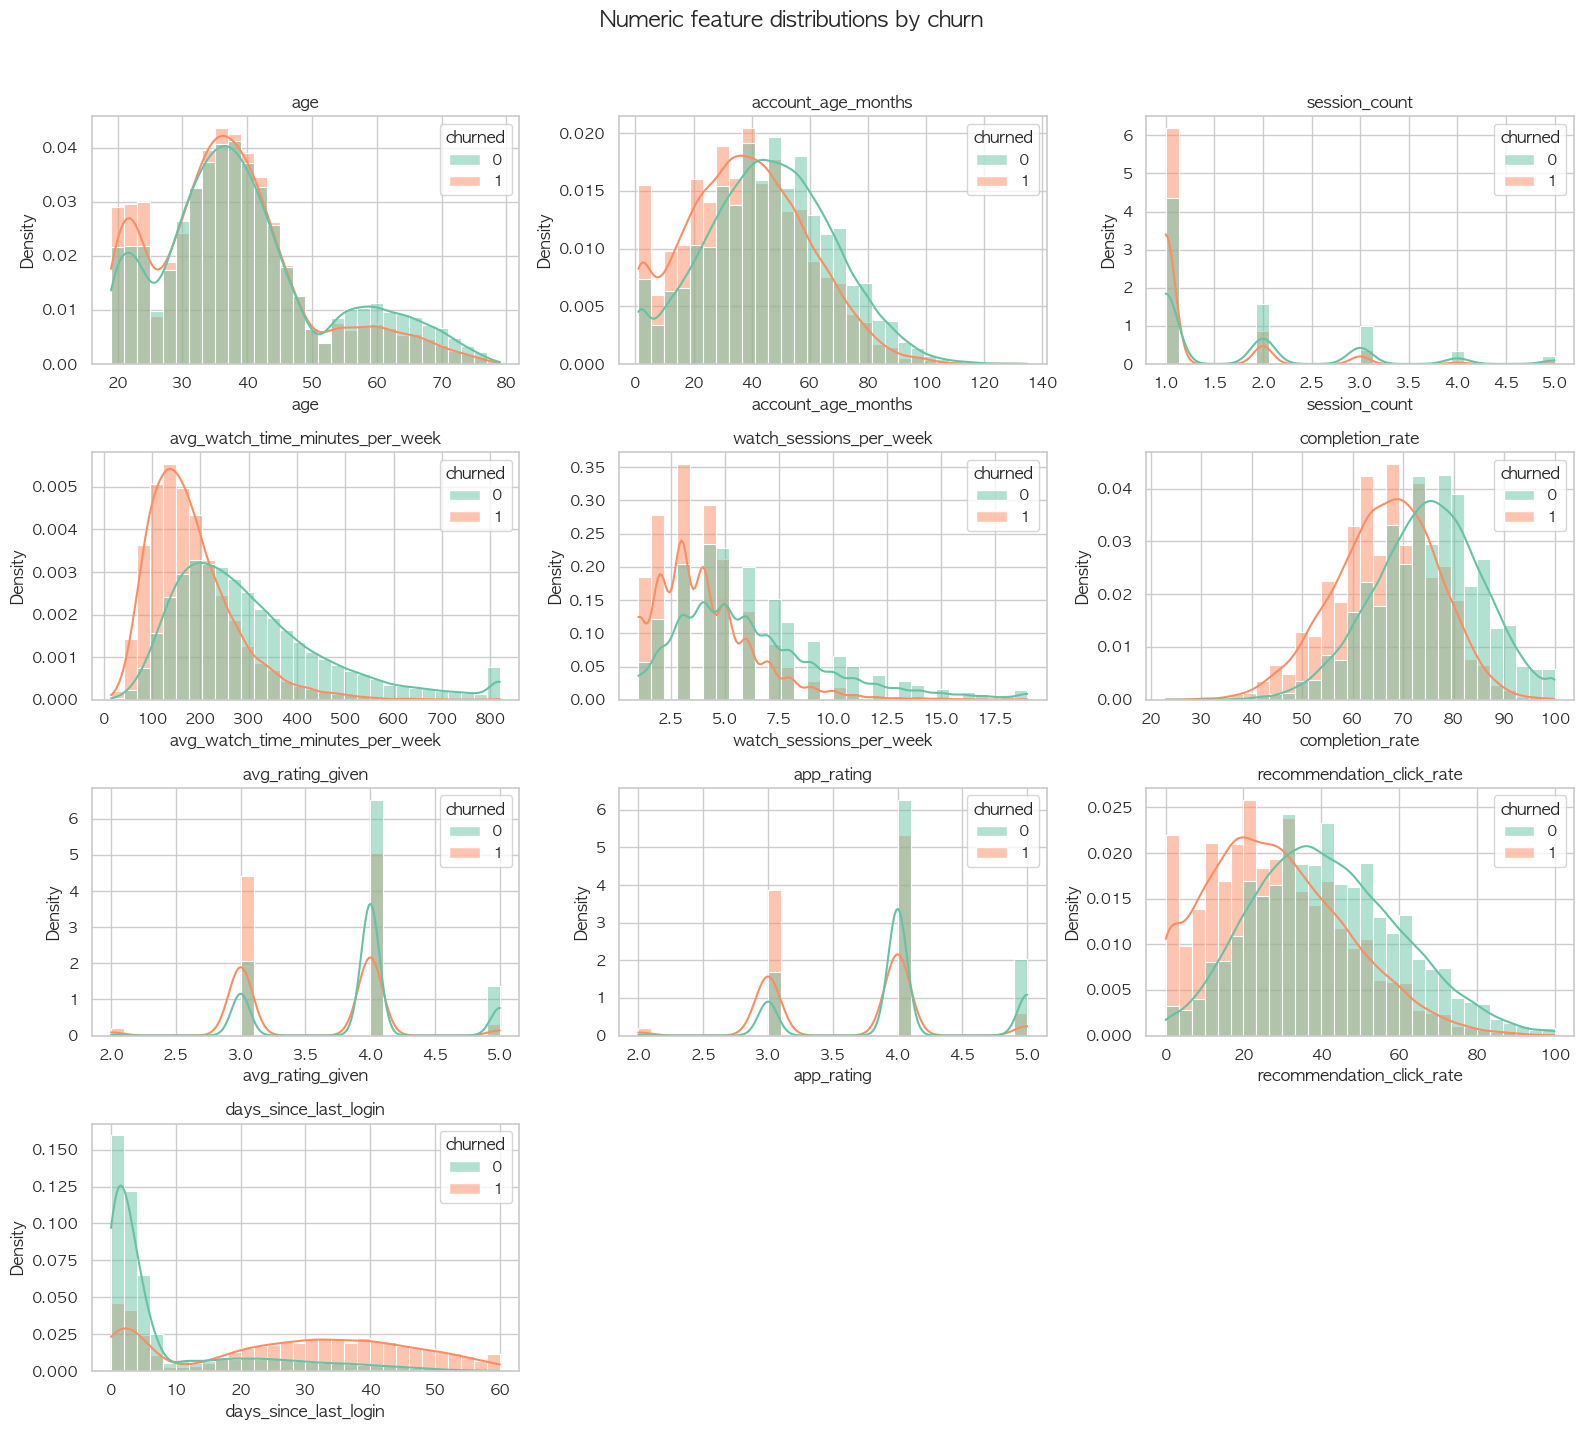

In [41]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, hue='churned', bins=30, kde=True, stat='density', common_norm=False, ax=ax)
    ax.set_title(col)

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

fig.suptitle('Numeric feature distributions by churn', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

**해석**

- `age`: 이탈 고객 평균은 37.3세, 유지 고객 평균은 39.7세로 이탈 고객이 약간 더 낮다. 다만 두 분포가 많이 겹쳐 나이 단독으로는 이탈을 강하게 구분하기 어렵다.
- `account_age_months`: 이탈 고객 평균은 38.3개월, 유지 고객 평균은 46.5개월이다. 계정 사용 기간이 짧은 고객일수록 이탈 쪽 분포가 더 두드러진다.
- `session_count`: 이탈 고객 평균은 1.25회, 유지 고객 평균은 1.73회로 유지 고객이 더 높다. 하지만 두 그룹 모두 1회 근처에 많이 몰려 있어 단독 분리력은 제한적이다.
- `avg_watch_time_minutes_per_week`: 이탈 고객 평균은 181.3분, 유지 고객 평균은 303.6분이다. 주당 시청 시간이 낮은 구간에서 이탈 고객 비중이 더 높게 나타난다.
- `watch_sessions_per_week`: 이탈 고객 평균은 4.0회, 유지 고객 평균은 6.2회다. 시청 세션이 적을수록 이탈 가능성이 높아지는 패턴이 보인다.
- `completion_rate`: 이탈 고객 평균은 66.6%, 유지 고객 평균은 74.9%다. 콘텐츠를 끝까지 보는 비율이 낮은 고객이 이탈 쪽으로 더 많이 분포한다.
- `avg_rating_given`: 이탈 고객 평균은 3.55점, 유지 고객 평균은 3.92점이다. 평점을 낮게 주는 고객일수록 만족도가 낮고 이탈 가능성이 커질 수 있다.
- `app_rating`: 이탈 고객 평균은 3.63점, 유지 고객 평균은 4.03점이다. 앱 평가가 낮은 그룹에서 이탈 분포가 더 높게 나타난다.
- `recommendation_click_rate`: 이탈 고객 평균은 28.4%, 유지 고객 평균은 41.4%다. 추천 콘텐츠를 덜 클릭하는 고객은 서비스 반응성이 낮아 이탈 위험이 커 보인다.
- `days_since_last_login`: 이탈 고객 평균은 27.2일, 유지 고객 평균은 8.3일이다. 최근 로그인 공백이 길수록 이탈 고객 분포가 뚜렷하게 증가하며, 수치형 변수 중 가장 강한 차이를 보인다.

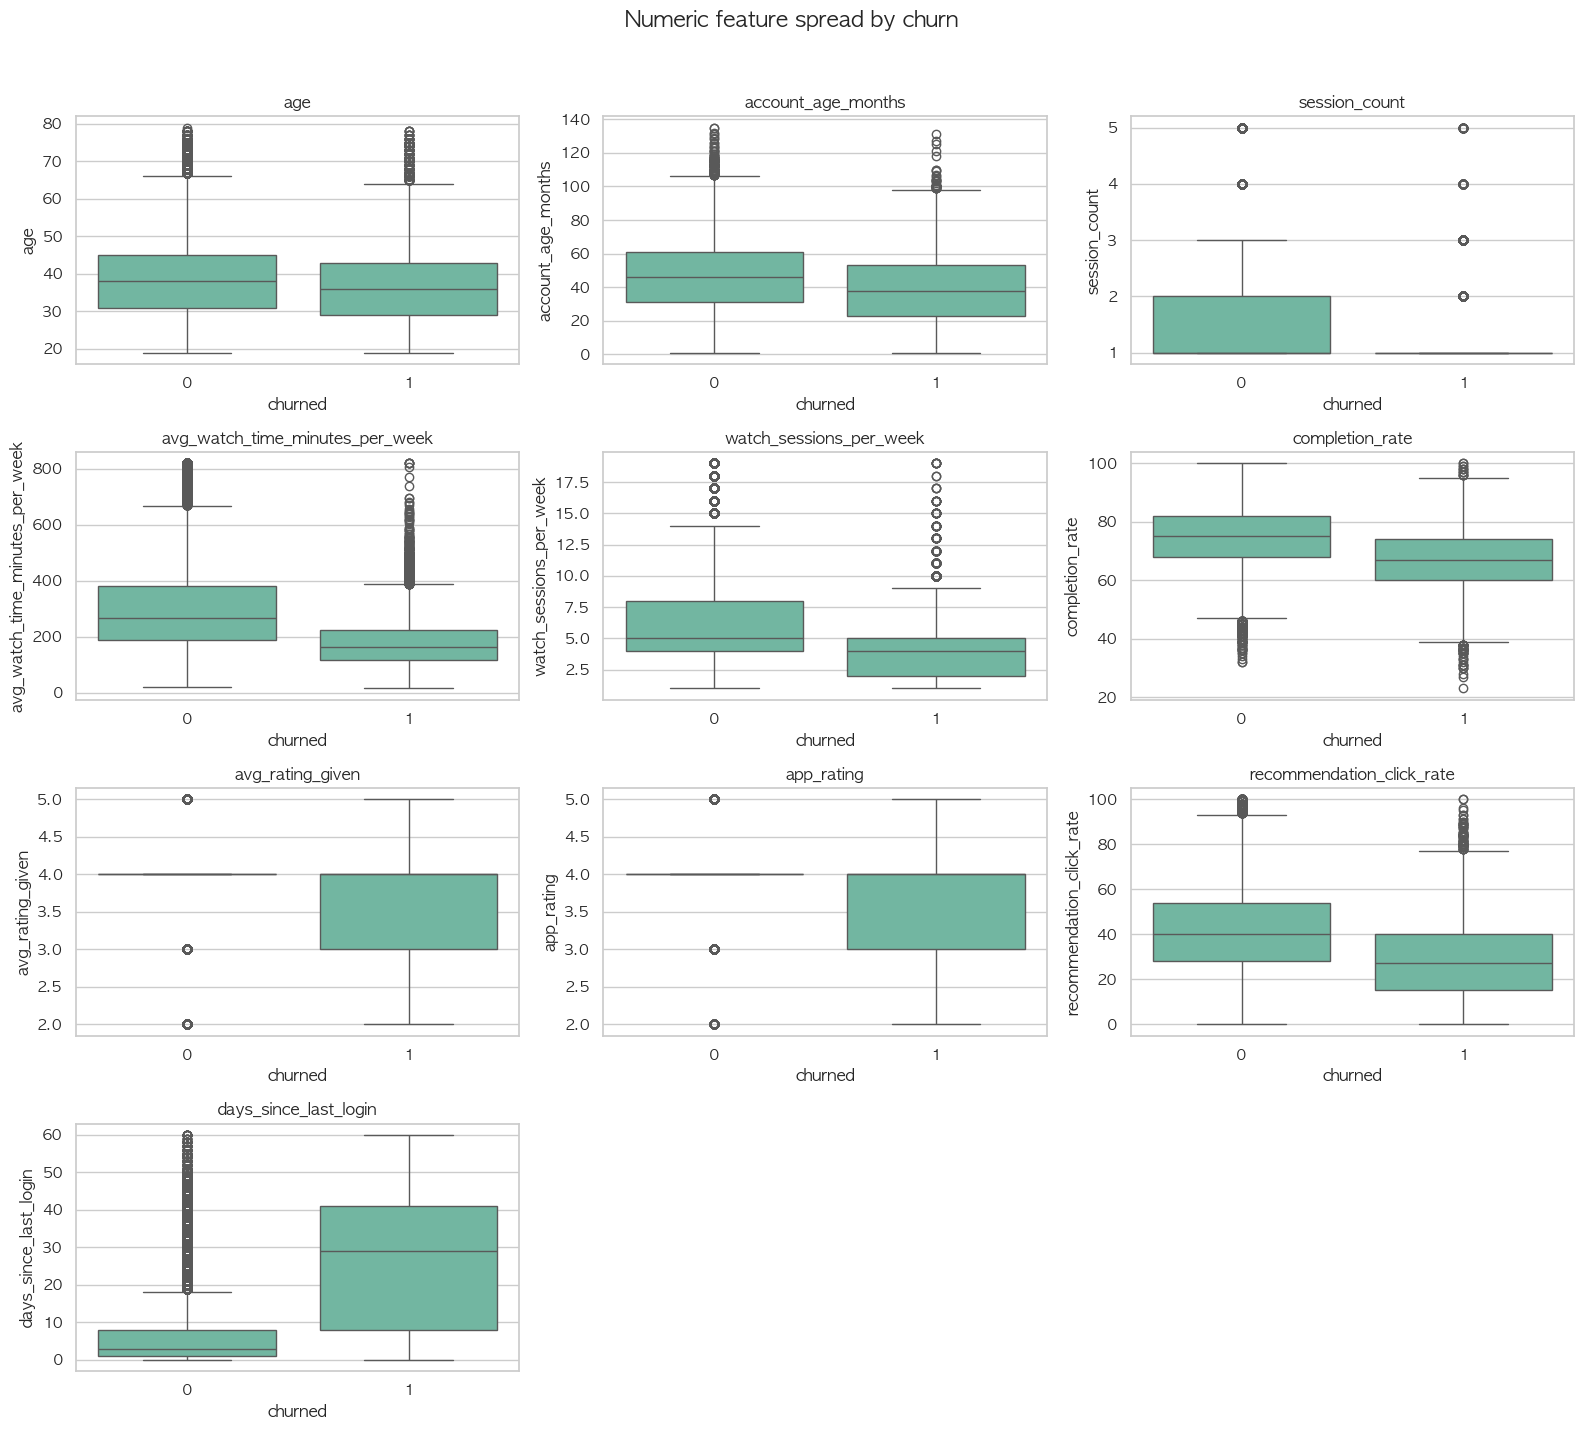

In [42]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='churned', y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('churned')

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

fig.suptitle('Numeric feature spread by churn', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

**해석**

- `age`: 중앙값은 유지 고객 38세, 이탈 고객 36세로 이탈 고객이 약간 낮다. 그러나 박스 범위가 크게 겹쳐 나이만으로 이탈 여부를 구분하기는 어렵다.
- `account_age_months`: 중앙값은 유지 고객 46개월, 이탈 고객 38개월이다. 계정 사용 기간이 짧은 고객군에서 이탈이 더 많이 나타난다.
- `session_count`: 두 그룹의 중앙값이 모두 1이다. 유지 고객 쪽에 상대적으로 높은 값이 더 있지만, boxplot 기준으로는 분리력이 강하지 않다.
- `avg_watch_time_minutes_per_week`: 중앙값은 유지 고객 267분, 이탈 고객 164분이다. 유지 고객의 시청 시간이 전반적으로 더 높고, 이탈 고객은 낮은 시청 시간 구간에 집중된다.
- `watch_sessions_per_week`: 중앙값은 유지 고객 5회, 이탈 고객 4회다. 유지 고객의 주당 시청 빈도가 더 높다.
- `completion_rate`: 중앙값은 유지 고객 75%, 이탈 고객 67%다. 이탈 고객은 콘텐츠 완료율이 낮은 방향으로 분포한다.
- `avg_rating_given`: 두 그룹의 중앙값은 모두 4점이다. 중앙값만 보면 차이가 작지만, 평균은 이탈 고객이 더 낮아 낮은 평점 쪽 꼬리가 이탈 그룹에 더 많다.
- `app_rating`: 두 그룹의 중앙값은 모두 4점이다. 다만 평균은 유지 고객 4.03점, 이탈 고객 3.63점으로 이탈 고객의 앱 평가가 낮은 쪽으로 기울어 있다.
- `recommendation_click_rate`: 중앙값은 유지 고객 40%, 이탈 고객 27%다. 추천 콘텐츠 반응률이 낮은 고객일수록 이탈 쪽에 더 가깝다.
- `days_since_last_login`: 중앙값은 유지 고객 3일, 이탈 고객 29일로 차이가 가장 크다. 최근 로그인 공백은 이탈 여부를 설명하는 핵심 변수로 보인다.

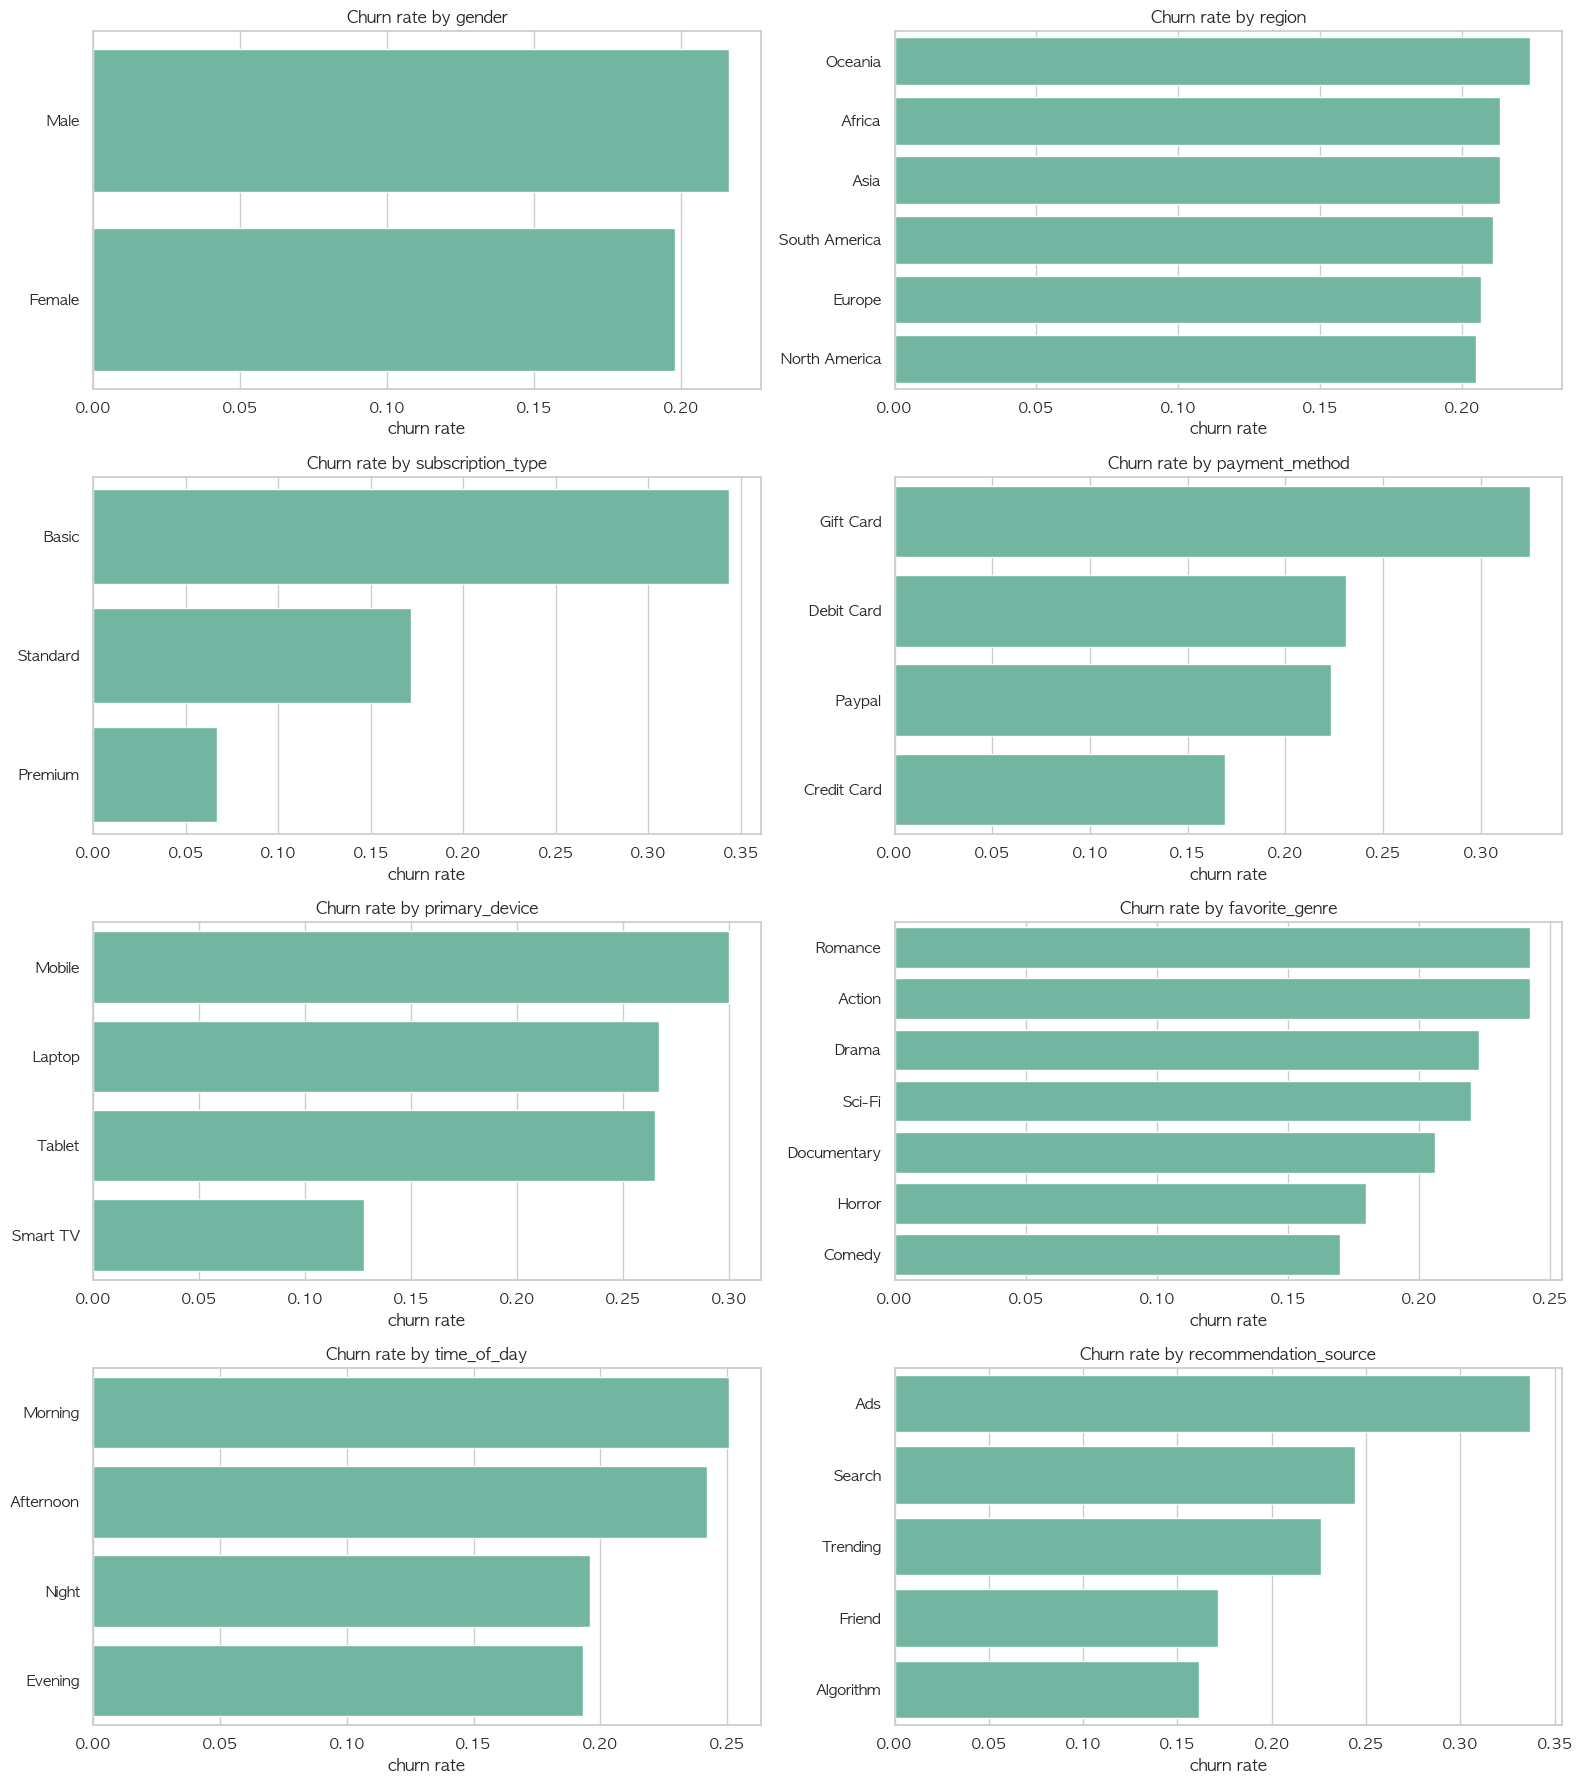

In [43]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.ravel()

for ax, col in zip(axes, categorical_cols):
    churn_rate = (
        df.groupby(col)['churned']
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    sns.barplot(data=churn_rate, x='churned', y=col, ax=ax)
    ax.set_title(f'Churn rate by {col}')
    ax.set_xlabel('churn rate')
    ax.set_ylabel('')

for ax in axes[len(categorical_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**해석**

- `gender`: 남성 이탈률은 21.6%, 여성 이탈률은 19.8%다. 차이는 있지만 다른 범주형 변수에 비해 크지 않다.
- `region`: 이탈률은 Oceania 22.4%, Africa 21.3%, Asia 21.3%, South America 21.1%, Europe 20.7%, North America 20.5% 순이다. 지역별 차이는 전반적으로 작다.
- `subscription_type`: Basic 34.4%, Standard 17.2%, Premium 6.7% 순으로 이탈률 차이가 매우 크다. 낮은 요금제일수록 이탈 위험이 높고, Premium 고객은 유지 가능성이 높아 보인다.
- `payment_method`: Gift Card 32.6%, Debit Card 23.1%, Paypal 22.3%, Credit Card 16.9% 순이다. Gift Card 사용자는 이탈률이 높고, Credit Card 사용자는 상대적으로 안정적이다.
- `primary_device`: Mobile 30.0%, Laptop 26.7%, Tablet 26.5%, Smart TV 12.8% 순이다. Smart TV 중심 사용자는 이탈률이 낮고, 모바일 중심 사용자는 이탈률이 높다.
- `favorite_genre`: Romance 24.2%, Action 24.2%, Drama 22.3%, Sci-Fi 22.0%, Documentary 20.6%, Horror 18.0%, Comedy 17.0% 순이다. 장르별 차이는 있지만 구독 유형이나 기기만큼 크지는 않다.
- `time_of_day`: Morning 25.1%, Afternoon 24.2%, Night 19.6%, Evening 19.3% 순이다. 오전/오후 이용 고객이 저녁/밤 이용 고객보다 이탈률이 높다.
- `recommendation_source`: Ads 33.7%, Search 24.4%, Trending 22.6%, Friend 17.1%, Algorithm 16.2% 순이다. 광고 유입 고객은 이탈률이 높고, 알고리즘 추천 유입 고객은 이탈률이 낮다.

In [44]:
df.groupby('churned')[numeric_cols].agg(['mean', 'median', 'std']).T

churned                                      0       1
age                             mean    39.730  37.283
                                median  38.000  36.000
                                std     13.281  12.058
account_age_months              mean    46.540  38.272
                                median  46.000  38.000
                                std     21.783  21.042
session_count                   mean     1.731   1.251
                                median   1.000   1.000
                                std      1.043   0.617
avg_watch_time_minutes_per_week mean   303.642 181.302
                                median 267.000 164.000
                                std    161.523  91.168
watch_sessions_per_week         mean     6.196   3.985
                                median   5.000   4.000
                                std      3.567   2.350
completion_rate                 mean    74.874  66.556
                                median  75.000  67.000
                                std     10.702  10.312
avg_rating_given                mean     3.923   3.549
                                median   4.000   4.000
                                std      0.592   0.594
app_rating                      mean     4.029   3.634
                                median   4.000   4.000
                                std      0.616   0.627
recommendation_click_rate       mean    41.358  28.417
                                median  40.000  27.000
                                std     18.972  17.877
days_since_last_login           mean     8.333  27.229
                                median   3.000  29.000
                                std     12.026  17.640

In [45]:
for col in categorical_cols:
    display(
        pd.crosstab(df[col], df['churned'], normalize='index')
        .rename(columns={0: 'retained_ratio', 1: 'churned_ratio'})
        .sort_values('churned_ratio', ascending=False)
    )

churned,retained_ratio,churned_ratio
gender,,
Male,0.784,0.216
Female,0.802,0.198


churned,retained_ratio,churned_ratio
region,,
Oceania,0.776,0.224
Africa,0.787,0.213
Asia,0.787,0.213
South America,0.789,0.211
Europe,0.793,0.207
North America,0.795,0.205


churned,retained_ratio,churned_ratio
subscription_type,,
Basic,0.656,0.344
Standard,0.828,0.172
Premium,0.933,0.067


churned,retained_ratio,churned_ratio
payment_method,,
Gift Card,0.674,0.326
Debit Card,0.769,0.231
Paypal,0.777,0.223
Credit Card,0.831,0.169


churned,retained_ratio,churned_ratio
primary_device,,
Mobile,0.700,0.300
Laptop,0.733,0.267
Tablet,0.735,0.265
Smart TV,0.872,0.128


churned,retained_ratio,churned_ratio
favorite_genre,,
Romance,0.758,0.242
Action,0.758,0.242
Drama,0.777,0.223
Sci-Fi,0.780,0.220
Documentary,0.794,0.206
Horror,0.820,0.180
Comedy,0.830,0.170


churned,retained_ratio,churned_ratio
time_of_day,,
Morning,0.749,0.251
Afternoon,0.758,0.242
Night,0.804,0.196
Evening,0.807,0.193


churned,retained_ratio,churned_ratio
recommendation_source,,
Ads,0.663,0.337
Search,0.756,0.244
Trending,0.774,0.226
Friend,0.829,0.171
Algorithm,0.838,0.162


### 수치형 변수 상관관계

In [46]:
corr_with_target = (
    df[numeric_cols + ['churned']]
    .corr(numeric_only=True)['churned']
    .drop('churned')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_with_target

days_since_last_login              0.498
avg_watch_time_minutes_per_week   -0.316
completion_rate                   -0.304
recommendation_click_rate         -0.271
watch_sessions_per_week           -0.260
app_rating                        -0.252
avg_rating_given                  -0.249
session_count                     -0.198
account_age_months                -0.154
age                               -0.076
Name: churned, dtype: float64

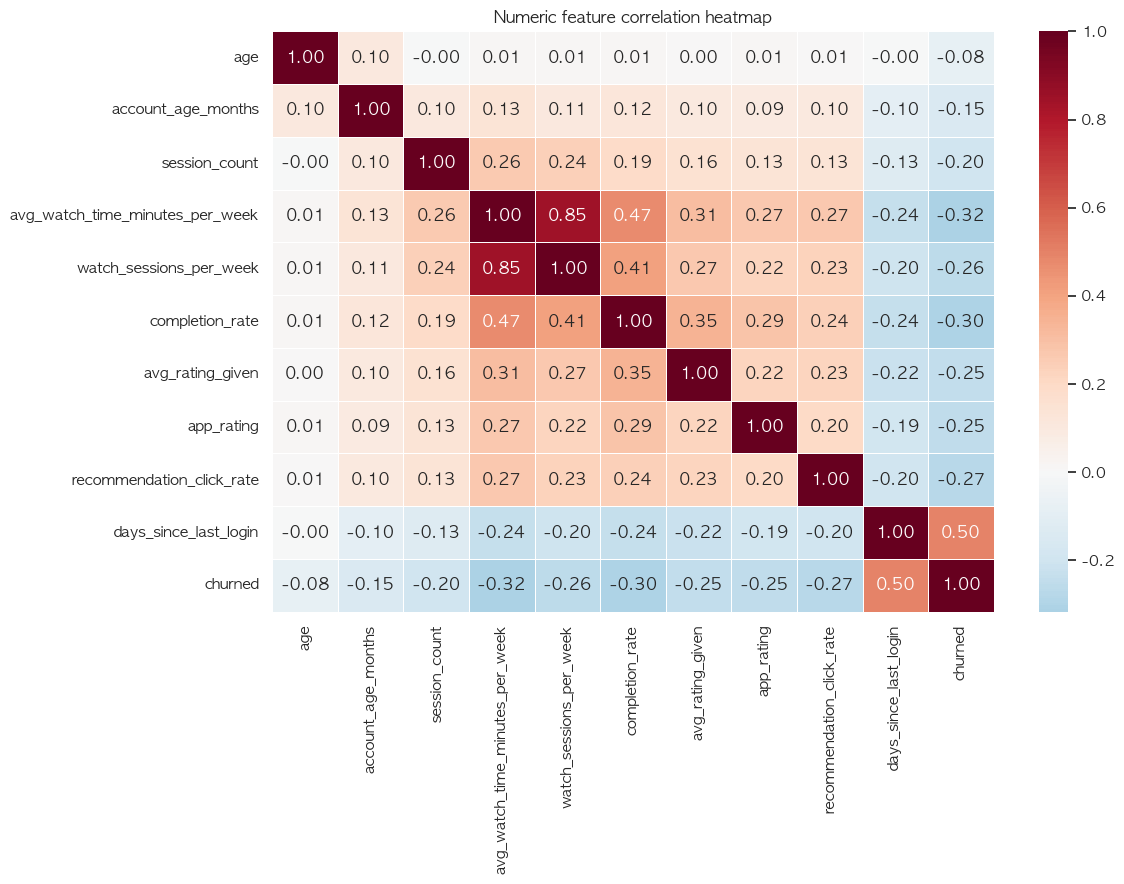

In [47]:
plt.figure(figsize=(12, 9))
sns.heatmap(
    df[numeric_cols + ['churned']].corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
)
plt.title('Numeric feature correlation heatmap')
plt.tight_layout()
plt.show()

**해석**

- `days_since_last_login`: `churned`와의 상관계수는 약 0.50으로 가장 크다. 마지막 로그인 이후 시간이 길수록 이탈 가능성이 커지는 방향이다.
- `avg_watch_time_minutes_per_week`: `churned`와 약 -0.32의 상관을 가진다. 주당 시청 시간이 길수록 이탈 가능성은 낮아진다.
- `completion_rate`: `churned`와 약 -0.30의 상관을 가진다. 콘텐츠 완료율이 높을수록 이탈 위험이 낮아지는 패턴이다.
- `recommendation_click_rate`: `churned`와 약 -0.27의 상관을 가진다. 추천 콘텐츠를 잘 클릭하는 고객은 이탈 가능성이 낮다.
- `watch_sessions_per_week`: `churned`와 약 -0.26의 상관을 가진다. 시청 빈도가 높을수록 유지 고객 쪽에 가깝다.
- `app_rating`: `churned`와 약 -0.25의 상관을 가진다. 앱 평가가 낮을수록 이탈 가능성이 높아지는 방향이다.
- `avg_rating_given`: `churned`와 약 -0.25의 상관을 가진다. 콘텐츠에 낮은 평점을 주는 경향도 이탈과 연결된다.
- `session_count`: `churned`와 약 -0.20의 상관을 가진다. 접속 세션 수가 많을수록 이탈 가능성은 낮지만, 앞선 사용량 변수들보다는 약하다.
- `account_age_months`: `churned`와 약 -0.15의 상관을 가진다. 오래된 계정일수록 유지 가능성이 약간 높다.
- `age`: `churned`와 약 -0.08의 상관으로 가장 약하다. 나이는 이탈 설명력이 상대적으로 낮다.
- 전체적으로 heatmap은 로그인 공백, 시청 활동량, 콘텐츠 반응성, 만족도 변수가 이탈과 연결된다는 점을 보여준다. 다만 상관계수는 선형 관계만 보는 지표이므로 범주형 변수와 비선형 패턴은 모델링 단계에서 함께 확인해야 한다.

## 세그먼트 분석

EDA에서 이탈과 관련성이 컸던 로그인 공백, 시청 활동량, 만족도, 요금제, 기기, 유입 경로, 선호 장르를 기준으로 고객군을 나누어 이탈률을 비교한다.

In [48]:
seg = df.copy()

seg['login_recency_segment'] = pd.cut(
    seg['days_since_last_login'],
    bins=[-1, 3, 14, 30, float('inf')],
    labels=['0-3일', '4-14일', '15-30일', '31일 이상'],
)

engagement_cols = [
    'avg_watch_time_minutes_per_week',
    'watch_sessions_per_week',
    'completion_rate',
    'recommendation_click_rate',
]
seg['engagement_score'] = seg[engagement_cols].rank(pct=True).mean(axis=1)
seg['engagement_segment'] = pd.qcut(
    seg['engagement_score'],
    q=3,
    labels=['저활동', '중활동', '고활동'],
)

satisfaction_cols = ['avg_rating_given', 'app_rating']
seg['satisfaction_score'] = seg[satisfaction_cols].mean(axis=1)
seg['satisfaction_segment'] = pd.cut(
    seg['satisfaction_score'],
    bins=[0, 3.5, 4.0, 5.0],
    labels=['낮음', '보통', '높음'],
    include_lowest=True,
)

seg[['login_recency_segment', 'engagement_segment', 'satisfaction_segment']].head()

,login_recency_segment,engagement_segment,satisfaction_segment
0,0-3일,중활동,보통
1,15-30일,저활동,보통
2,4-14일,중활동,낮음
3,31일 이상,중활동,보통
4,4-14일,저활동,높음


In [49]:
def segment_summary(data, group_cols, min_count=100):
    summary = (
        data.groupby(group_cols, observed=True)
        .agg(
            users=('user_id', 'count'),
            churners=('churned', 'sum'),
            churn_rate=('churned', 'mean'),
            avg_days_since_last_login=('days_since_last_login', 'mean'),
            avg_watch_time=('avg_watch_time_minutes_per_week', 'mean'),
            avg_completion_rate=('completion_rate', 'mean'),
            avg_recommendation_click_rate=('recommendation_click_rate', 'mean'),
        )
        .reset_index()
        .query('users >= @min_count')
        .sort_values('churn_rate', ascending=False)
    )
    return summary

overall_churn_rate = seg['churned'].mean()
overall_churn_rate

np.float64(0.21)

### 단일 세그먼트별 이탈률

In [50]:
one_way_segments = [
    'login_recency_segment',
    'engagement_segment',
    'satisfaction_segment',
    'subscription_type',
    'primary_device',
    'favorite_genre',
    'recommendation_source',
]

one_way_summary = pd.concat(
    [
        segment_summary(seg, [col], min_count=1).assign(segment_type=col).rename(columns={col: 'segment'})
        for col in one_way_segments
    ],
    ignore_index=True,
)

one_way_summary[['segment_type', 'segment', 'users', 'churners', 'churn_rate']].sort_values(
    ['segment_type', 'churn_rate'],
    ascending=[True, False],
)

,segment_type,segment,users,churners,churn_rate
4,engagement_segment,저활동,16667,6993,0.420
5,engagement_segment,중활동,16666,2732,0.164
6,engagement_segment,고활동,16667,775,0.046
17,favorite_genre,Romance,4500,1091,0.242
18,favorite_genre,Action,8000,1937,0.242
19,favorite_genre,Drama,9000,2004,0.223
20,favorite_genre,Sci-Fi,6500,1428,0.220
21,favorite_genre,Documentary,7000,1441,0.206
22,favorite_genre,Horror,5000,899,0.180
23,favorite_genre,Comedy,10000,1700,0.170


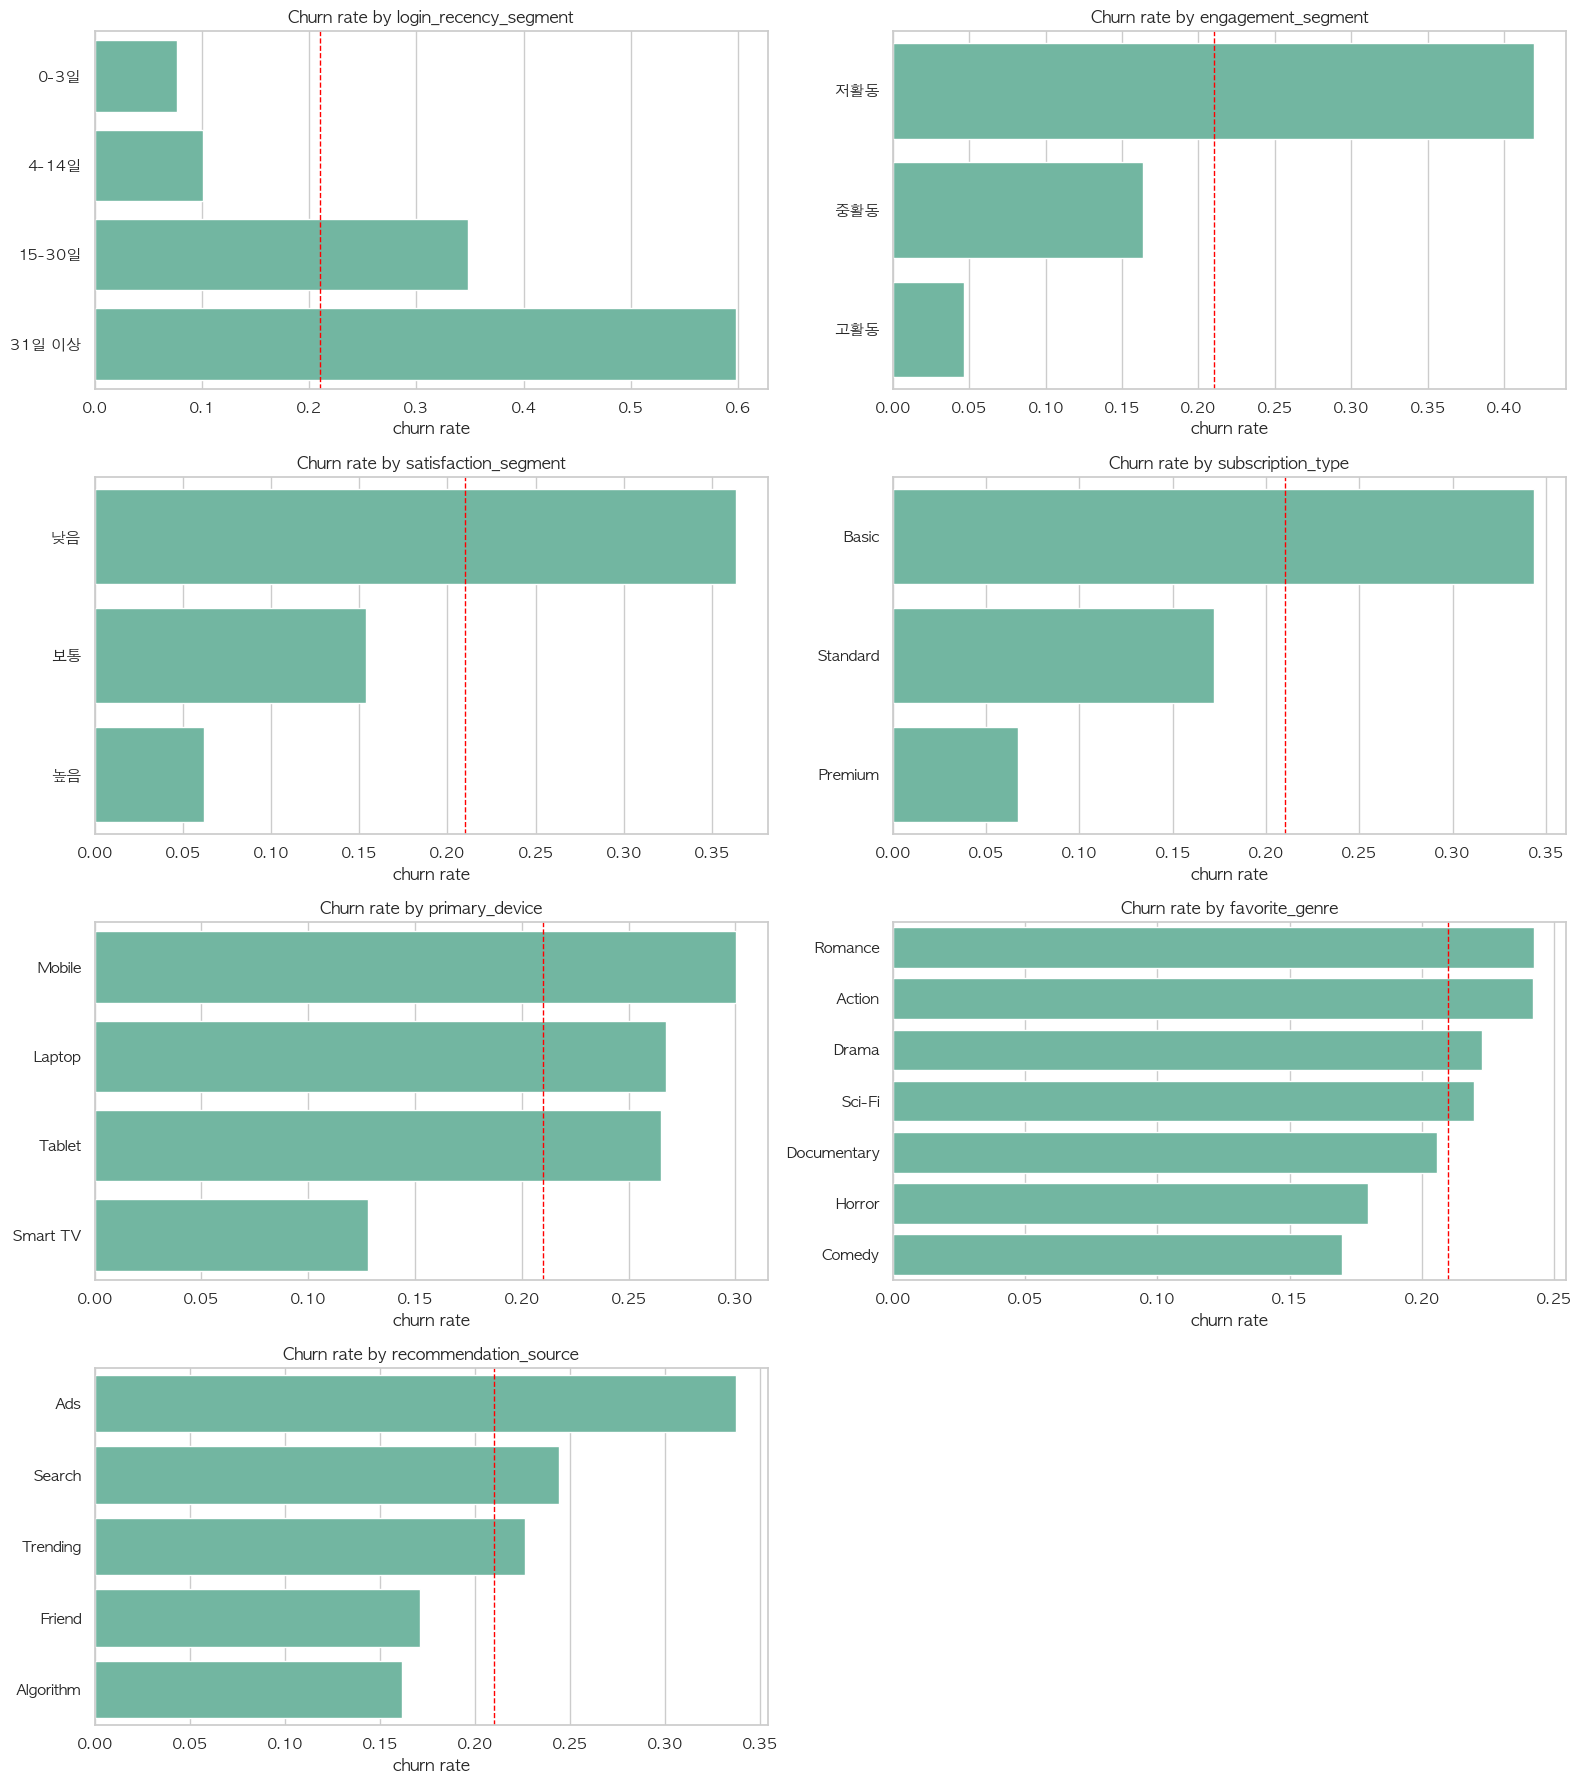

In [51]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.ravel()

for ax, col in zip(axes, one_way_segments):
    plot_data = segment_summary(seg, [col], min_count=1).sort_values('churn_rate', ascending=False)
    sns.barplot(data=plot_data, x='churn_rate', y=col, ax=ax)
    ax.axvline(overall_churn_rate, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'Churn rate by {col}')
    ax.set_xlabel('churn rate')
    ax.set_ylabel('')

for ax in axes[len(one_way_segments):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**해석**

- 빨간 점선은 전체 평균 이탈률(21%)이다. 각 세그먼트의 막대가 점선보다 오른쪽에 있으면 평균보다 위험한 고객군이다.
- 로그인 공백이 긴 세그먼트일수록 이탈률이 높아질 가능성이 크다. 특히 `31일 이상` 고객군은 우선 관리 대상이다.
- 활동 세그먼트는 `저활동` 고객군의 이탈률이 높고, `고활동` 고객군은 낮게 나올 가능성이 크다.
- 만족도 세그먼트는 `낮음` 고객군의 이탈률이 높게 나타나는지 확인한다.
- 선호 장르별 이탈률을 보면 특정 콘텐츠 취향의 고객군이 더 잘 유지되는지 확인할 수 있다.
- 요금제, 주 사용 기기, 장르, 추천 경로는 앞선 EDA에서 차이가 있었으므로 단일 세그먼트만으로도 마케팅/리텐션 전략을 나누기 좋다.

### 교차 세그먼트별 이탈률

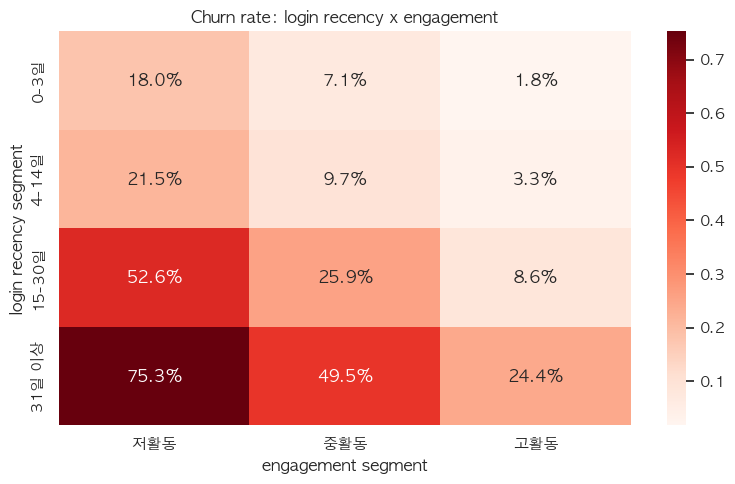

In [52]:
recency_engagement = pd.pivot_table(
    seg,
    values='churned',
    index='login_recency_segment',
    columns='engagement_segment',
    aggfunc='mean',
    observed=True,
)

plt.figure(figsize=(8, 5))
sns.heatmap(recency_engagement, annot=True, fmt='.1%', cmap='Reds')
plt.title('Churn rate: login recency x engagement')
plt.xlabel('engagement segment')
plt.ylabel('login recency segment')
plt.tight_layout()
plt.show()

**해석**

- 로그인 공백과 활동 수준을 함께 보면 이탈 위험이 더 명확해진다.
- `31일 이상`이면서 `저활동`인 고객군은 가장 위험한 조합으로 볼 수 있다.
- 반대로 `0-3일` 이내 로그인했고 `고활동`인 고객군은 유지 가능성이 높은 핵심 활성 고객군이다.
- 이 조합은 리텐션 캠페인 우선순위를 정할 때 바로 사용할 수 있다.

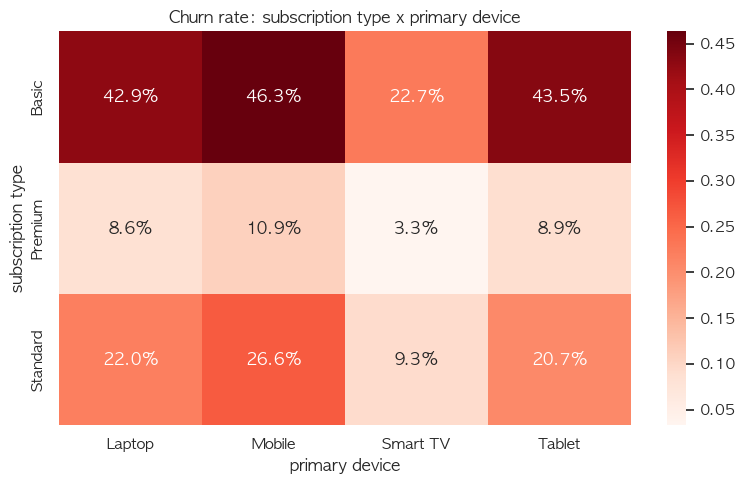

In [53]:
plan_device = pd.pivot_table(
    seg,
    values='churned',
    index='subscription_type',
    columns='primary_device',
    aggfunc='mean',
    observed=True,
)

plt.figure(figsize=(8, 5))
sns.heatmap(plan_device, annot=True, fmt='.1%', cmap='Reds')
plt.title('Churn rate: subscription type x primary device')
plt.xlabel('primary device')
plt.ylabel('subscription type')
plt.tight_layout()
plt.show()

**해석**

- 요금제와 기기 조합은 가격 민감도와 이용 맥락을 함께 보여준다.
- `Basic`이면서 `Mobile` 중심인 고객군은 평균보다 이탈 위험이 높을 가능성이 크다.
- `Premium`이면서 `Smart TV` 중심인 고객군은 안정적인 유지 고객군으로 볼 수 있다.
- 같은 요금제 안에서도 기기에 따라 이탈률 차이가 나는지 확인하면 타겟 메시지를 더 세밀하게 만들 수 있다.

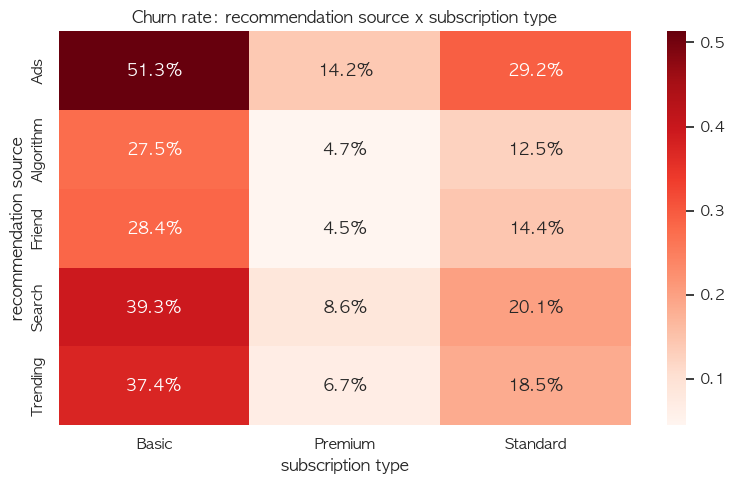

In [54]:
source_plan = pd.pivot_table(
    seg,
    values='churned',
    index='recommendation_source',
    columns='subscription_type',
    aggfunc='mean',
    observed=True,
)

plt.figure(figsize=(8, 5))
sns.heatmap(source_plan, annot=True, fmt='.1%', cmap='Reds')
plt.title('Churn rate: recommendation source x subscription type')
plt.xlabel('subscription type')
plt.ylabel('recommendation source')
plt.tight_layout()
plt.show()

**해석**

- 유입 경로와 요금제를 함께 보면 광고/추천 채널의 고객 품질을 비교할 수 있다.
- `Ads` 유입 고객 중 `Basic` 요금제 고객은 고위험 세그먼트일 가능성이 높다.
- `Algorithm` 유입 고객과 `Premium` 고객 조합은 상대적으로 안정적인 세그먼트일 가능성이 크다.
- 채널별 캠페인 성과를 단순 유입 수가 아니라 이탈률까지 함께 평가해야 한다.

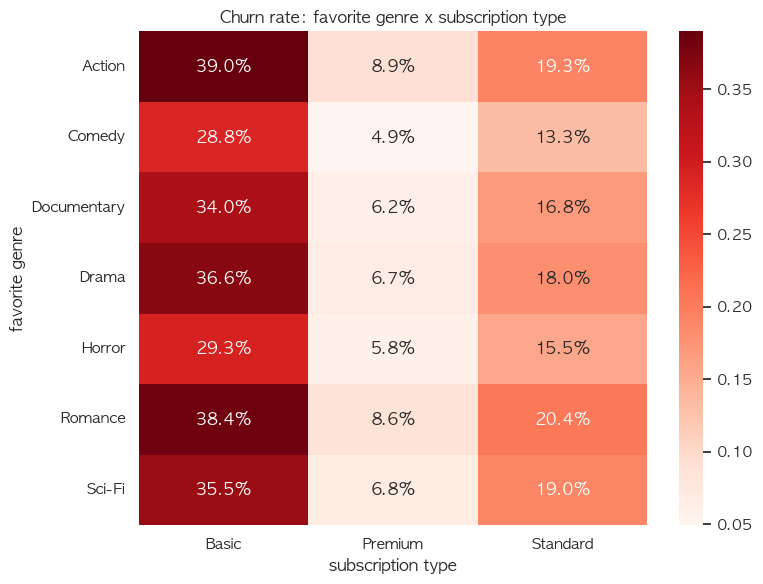

In [55]:
genre_plan = pd.pivot_table(
    seg,
    values='churned',
    index='favorite_genre',
    columns='subscription_type',
    aggfunc='mean',
    observed=True,
)

plt.figure(figsize=(8, 6))
sns.heatmap(genre_plan, annot=True, fmt='.1%', cmap='Reds')
plt.title('Churn rate: favorite genre x subscription type')
plt.xlabel('subscription type')
plt.ylabel('favorite genre')
plt.tight_layout()
plt.show()

**해석**

- 장르와 요금제를 함께 보면 콘텐츠 취향과 가격 민감도가 동시에 반영된 고객군을 볼 수 있다.
- 단일 장르 기준으로는 Romance, Action 쪽 이탈률이 높고 Comedy, Horror 쪽 이탈률이 낮게 나타났으므로, 요금제와 결합했을 때도 같은 패턴이 유지되는지 확인한다.
- 특정 장르에서 `Basic` 고객의 이탈률이 특히 높다면, 해당 장르 고객에게 콘텐츠 추천 강화나 요금제 업그레이드 혜택을 실험해볼 수 있다.
- `Premium` 고객은 전반적으로 이탈률이 낮지만, 장르별로 예외가 있는지 확인하면 고가치 고객 관리 포인트를 찾을 수 있다.

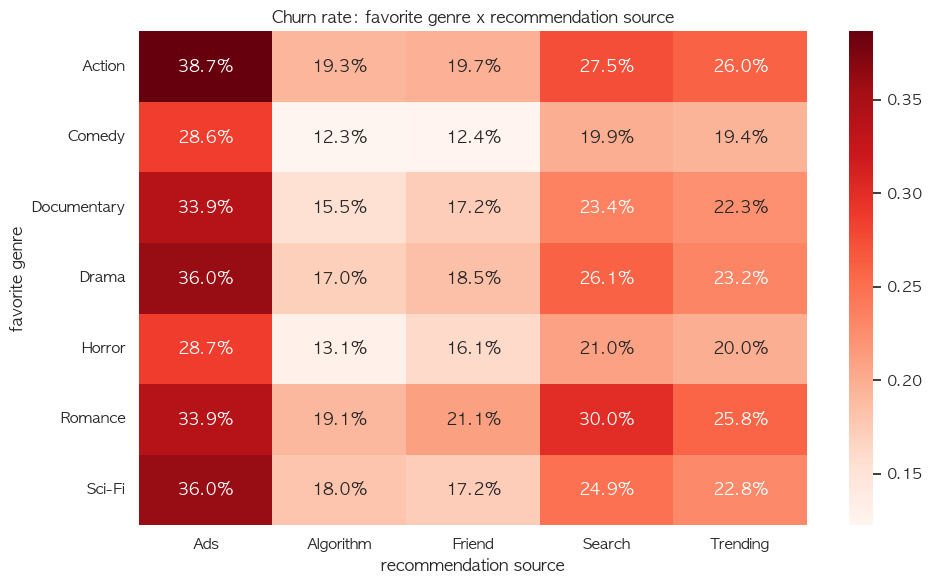

In [56]:
genre_source = pd.pivot_table(
    seg,
    values='churned',
    index='favorite_genre',
    columns='recommendation_source',
    aggfunc='mean',
    observed=True,
)

plt.figure(figsize=(10, 6))
sns.heatmap(genre_source, annot=True, fmt='.1%', cmap='Reds')
plt.title('Churn rate: favorite genre x recommendation source')
plt.xlabel('recommendation source')
plt.ylabel('favorite genre')
plt.tight_layout()
plt.show()

**해석**

- 장르와 추천 경로를 함께 보면 어떤 콘텐츠 취향의 고객이 어떤 유입/추천 경로에서 이탈하기 쉬운지 볼 수 있다.
- `Ads` 유입은 전체적으로 이탈률이 높았기 때문에, 장르별로 광고 유입 고객의 품질 차이를 확인한다.
- `Algorithm` 유입은 전체적으로 안정적이었으므로, 장르별 알고리즘 추천이 유지율 개선에 얼마나 일관적으로 작동하는지 확인할 수 있다.
- 장르별로 특정 추천 경로의 이탈률이 높다면, 해당 장르의 추천 메시지나 랜딩 콘텐츠가 기대와 맞지 않을 가능성이 있다.

### 고위험 세그먼트 추출

In [57]:
risk_segments = segment_summary(
    seg,
    [
        'login_recency_segment',
        'engagement_segment',
        'subscription_type',
        'primary_device',
        'favorite_genre',
        'recommendation_source',
    ],
    min_count=100,
)

risk_segments.assign(
    lift=lambda x: x['churn_rate'] / overall_churn_rate,
)[[
    'login_recency_segment',
    'engagement_segment',
    'subscription_type',
    'primary_device',
    'favorite_genre',
    'recommendation_source',
    'users',
    'churners',
    'churn_rate',
    'lift',
    'avg_days_since_last_login',
    'avg_watch_time',
]].head(20)

,login_recency_segment,engagement_segment,subscription_type,primary_device,favorite_genre,recommendation_source,users,churners,churn_rate,lift,avg_days_since_last_login,avg_watch_time
489,0-3일,중활동,Basic,Smart TV,Comedy,Algorithm,104,3,0.029,0.137,1.337,235.548
1192,0-3일,고활동,Standard,Smart TV,Drama,Algorithm,141,3,0.021,0.101,1.454,447.454
1054,0-3일,고활동,Premium,Smart TV,Drama,Algorithm,145,3,0.021,0.099,1.228,502.055
776,0-3일,중활동,Standard,Smart TV,Drama,Algorithm,104,2,0.019,0.092,1.452,257.577
1207,0-3일,고활동,Standard,Smart TV,Sci-Fi,Algorithm,131,2,0.015,0.073,1.420,457.786
1187,0-3일,고활동,Standard,Smart TV,Documentary,Algorithm,114,1,0.009,0.042,1.193,466.553
1177,0-3일,고활동,Standard,Smart TV,Action,Algorithm,138,1,0.007,0.035,1.232,464.514
1182,0-3일,고활동,Standard,Smart TV,Comedy,Algorithm,161,1,0.006,0.030,1.342,453.615
1044,0-3일,고활동,Premium,Smart TV,Comedy,Algorithm,212,1,0.005,0.022,1.217,483.995
905,0-3일,고활동,Basic,Smart TV,Comedy,Algorithm,131,0,0.000,0.000,1.420,440.985


**해석**

- `churn_rate`는 해당 세그먼트 내부의 이탈률이고, `lift`는 전체 평균 이탈률 대비 몇 배 위험한지를 뜻한다.
- `users`가 너무 작은 조합은 우연성이 클 수 있으므로 `min_count=100` 이상인 조합만 우선 확인한다.
- 상위 세그먼트는 리텐션 캠페인, 할인/업그레이드 제안, 개인화 추천 개선의 우선 대상이 된다.
- 단순히 이탈률만 높은 세그먼트보다 `users`, `churners`, `lift`가 모두 큰 세그먼트를 우선순위로 잡는 것이 실무적으로 유리하다.

## Business Insight

### Basic 이탈 고객을 위한 중간 요금제 도입

EDA와 세그먼트 분석에서 `Basic` 고객의 이탈률이 가장 높고, `Premium` 고객의 이탈률은 가장 낮게 나타났다. 이는 낮은 요금제를 사용하는 고객군이 가격에는 민감하지만, 현재 Basic 요금제의 서비스 경험만으로는 충분한 유지 동기를 얻지 못할 가능성을 보여준다.

따라서 Basic 고객을 바로 Premium으로 전환시키기보다는, Basic과 Standard 사이의 완충 역할을 하는 신규 요금제를 검토할 수 있다.

- `Basic Plus`: Basic보다 약간 높은 가격에 광고 감소, 추천 품질 강화, 일부 콘텐츠 혜택 제공
- `Mobile Plus`: 이탈률이 높은 모바일 중심 고객을 대상으로 한 저가형 모바일 최적화 요금제
- `Retention Plan`: 최근 로그인 공백이 길거나 저활동인 고객에게 한시적으로 제공하는 할인형 유지 요금제

핵심은 신규 요금제가 Premium을 대체하는 상품이 아니라, Basic 고객의 이탈을 막는 방어 상품이어야 한다는 점이다. 특히 `Basic + Mobile + Ads 유입 + 저활동` 조합은 고위험 세그먼트일 가능성이 높으므로, 이 고객군을 대상으로 신규 요금제 또는 혜택 제공 A/B 테스트를 설계할 수 있다.

## Feature Engineering

모델링에 바로 사용할 수 있도록 식별자 컬럼은 제거하고, EDA/세그먼트 분석에서 의미가 있었던 변수와 합성 컬럼을 중심으로 `model_df`를 만든다.

### 컬럼 정리 방향

- 제거: `user_id`는 식별자라 예측 신호로 사용하지 않는다.
- 제거: `region`, `gender`는 EDA에서 이탈률 차이가 작아 우선 제외한다.
- 중복 제거: 원본 연속형과 구간형/점수형 파생변수는 동시에 넣지 않는다.
- 유지: 요금제, 결제수단, 기기, 장르, 이용 시간대, 추천 경로처럼 이탈률 차이가 확인된 범주형 컬럼은 유지한다.
- 추가: 활동성, 만족도, 고위험 조합을 표현하는 합성 컬럼을 만들되, 같은 의미의 플래그를 과하게 중복 투입하지 않는다.
- 주의: `churned`는 타겟이므로 마지막에 따로 보관한다.

In [58]:
feature_df = df.copy()

# 1. 기본 구간화
feature_df['age_group'] = pd.cut(
    feature_df['age'],
    bins=[-1, 19, 29, 39, 49, 59, float('inf')],
    labels=['0~19세', '20대', '30대', '40대', '50대', '60세 이상'],
)

feature_df['account_age_segment'] = pd.cut(
    feature_df['account_age_months'],
    bins=[-1, 6, 24, 60, float('inf')],
    labels=['신규', '성장', '장기', '충성'],
)

feature_df['login_recency_segment'] = pd.cut(
    feature_df['days_since_last_login'],
    bins=[-1, 3, 14, 30, float('inf')],
    labels=['0-3일', '4-14일', '15-30일', '31일 이상'],
)

# 2. 사용 행동 합성 변수
feature_df['avg_watch_per_session'] = (
    feature_df['avg_watch_time_minutes_per_week']
    .div(feature_df['watch_sessions_per_week'].replace(0, pd.NA))
    .fillna(0)
)

feature_df['engagement_score'] = feature_df[
    [
        'avg_watch_time_minutes_per_week',
        'watch_sessions_per_week',
        'completion_rate',
        'recommendation_click_rate',
    ]
].rank(pct=True).mean(axis=1)

feature_df['engagement_segment'] = pd.qcut(
    feature_df['engagement_score'],
    q=3,
    labels=['저활동', '중활동', '고활동'],
)

# 3. 만족도 합성 변수
feature_df['satisfaction_score'] = feature_df[['avg_rating_given', 'app_rating']].mean(axis=1)
feature_df['rating_gap'] = feature_df['avg_rating_given'] - feature_df['app_rating']
feature_df['low_satisfaction_flag'] = feature_df['satisfaction_score'].lt(3.75).astype(int)

# 4. 리스크 플래그
feature_df['inactive_30d_flag'] = feature_df['days_since_last_login'].ge(30).astype(int)
feature_df['low_engagement_flag'] = feature_df['engagement_segment'].eq('저활동').astype(int)
feature_df['basic_plan_flag'] = feature_df['subscription_type'].eq('Basic').astype(int)
feature_df['mobile_user_flag'] = feature_df['primary_device'].eq('Mobile').astype(int)
feature_df['ads_source_flag'] = feature_df['recommendation_source'].eq('Ads').astype(int)
feature_df['high_risk_combo_flag'] = (
    feature_df['basic_plan_flag'].eq(1)
    & feature_df['mobile_user_flag'].eq(1)
    & feature_df['ads_source_flag'].eq(1)
    & feature_df['low_engagement_flag'].eq(1)
).astype(int)

# 5. 요금제 순서형 변수
feature_df['subscription_tier'] = feature_df['subscription_type'].map({
    'Basic': 1,
    'Standard': 2,
    'Premium': 3,
})

feature_df.head()

,user_id,age,gender,region,subscription_type,payment_method,primary_device,account_age_months,favorite_genre,time_of_day,recommendation_source,session_count,avg_watch_time_minutes_per_week,watch_sessions_per_week,completion_rate,avg_rating_given,app_rating,recommendation_click_rate,days_since_last_login,churned,age_group,account_age_segment,login_recency_segment,avg_watch_per_session,engagement_score,engagement_segment,satisfaction_score,rating_gap,low_satisfaction_flag,inactive_30d_flag,low_engagement_flag,basic_plan_flag,mobile_user_flag,ads_source_flag,high_risk_combo_flag,subscription_tier
0,N00001,33,Male,Europe,Basic,Credit Card,Smart TV,38,Comedy,Afternoon,Trending,1,259,4,79,4,4,48,3,0,30대,장기,0-3일,64.750,0.575,중활동,4.000,0,0,0,0,1,0,0,0,1
1,N00002,41,Male,Africa,Premium,Credit Card,Tablet,49,Comedy,Evening,Search,1,164,4,69,4,4,32,30,0,40대,장기,15-30일,41.000,0.336,저활동,4.000,0,0,1,1,0,0,0,0,3
2,N00003,28,Female,Europe,Standard,Gift Card,Laptop,20,Drama,Evening,Ads,1,304,5,75,4,3,31,5,1,20대,성장,4-14일,60.800,0.523,중활동,3.500,1,1,0,0,0,0,1,0,2
3,N00004,40,Female,North America,Basic,Credit Card,Mobile,19,Action,Evening,Algorithm,1,145,6,79,4,4,39,38,0,40대,성장,31일 이상,24.167,0.508,중활동,4.000,0,0,1,0,1,1,0,0,1
4,N00005,54,Male,Europe,Standard,Paypal,Mobile,51,Romance,Evening,Friend,3,108,1,58,5,4,50,5,0,50대,장기,4-14일,108.000,0.230,저활동,4.500,1,0,0,1,0,1,0,0,2


In [61]:
# 다중공선성/중복 정보 완화를 위해 같은 의미를 담는 원본-파생 피처는 하나만 선택한다.
# 예: age 대신 age_group, account_age_months 대신 account_age_segment,
#     여러 활동 지표 대신 engagement_score 중심으로 사용한다.

categorical_feature_cols = [
    'age_group',
    'account_age_segment',
    'subscription_type',
    'payment_method',
    'primary_device',
    'favorite_genre',
    'time_of_day',
    'recommendation_source',
]

numeric_feature_cols = [
    'session_count',
    'days_since_last_login',
    'avg_watch_per_session',
    'engagement_score',
    'satisfaction_score',
    'rating_gap',
    'high_risk_combo_flag',
]

target_col = 'churned'
model_feature_cols = categorical_feature_cols + numeric_feature_cols
model_df = feature_df[model_feature_cols + [target_col]].copy()


model_df.head()

,age_group,account_age_segment,subscription_type,payment_method,primary_device,favorite_genre,time_of_day,recommendation_source,session_count,days_since_last_login,avg_watch_per_session,engagement_score,satisfaction_score,rating_gap,high_risk_combo_flag,churned
0,30대,장기,Basic,Credit Card,Smart TV,Comedy,Afternoon,Trending,1,3,64.750,0.575,4.000,0,0,0
1,40대,장기,Premium,Credit Card,Tablet,Comedy,Evening,Search,1,30,41.000,0.336,4.000,0,0,0
2,20대,성장,Standard,Gift Card,Laptop,Drama,Evening,Ads,1,5,60.800,0.523,3.500,1,0,1
3,40대,성장,Basic,Credit Card,Mobile,Action,Evening,Algorithm,1,38,24.167,0.508,4.000,0,0,0
4,50대,장기,Standard,Paypal,Mobile,Romance,Evening,Friend,3,5,108.000,0.230,4.500,1,0,0


In [60]:
model_feature_summary = pd.DataFrame({
    'dtype': model_df.dtypes.astype(str),
    'missing': model_df.isna().sum(),
    'unique': model_df.nunique(),
})

model_feature_summary

,dtype,missing,unique
age_group,category,0,6
account_age_segment,category,0,4
subscription_type,str,0,3
payment_method,str,0,4
primary_device,str,0,4
favorite_genre,str,0,7
time_of_day,str,0,4
recommendation_source,str,0,5
session_count,int64,0,5
days_since_last_login,int64,0,61


**정리**

- `user_id`, `region`, `gender`는 제외했다. `user_id`는 식별자이고, `region`, `gender`는 EDA에서 이탈률 차이가 작았다.
- `age` 대신 `age_group`, `account_age_months` 대신 `account_age_segment`만 사용해 원본-구간형 중복을 줄였다.
- `avg_watch_time_minutes_per_week`, `watch_sessions_per_week`, `completion_rate`, `recommendation_click_rate`는 `engagement_score`에 반영되므로 최종 `model_df`에서는 제외했다.
- `avg_rating_given`, `app_rating`은 `satisfaction_score`, `rating_gap`으로 요약했다.
- `subscription_tier`, `basic_plan_flag`, `mobile_user_flag`, `ads_source_flag`, `inactive_30d_flag`, `low_engagement_flag`, `low_satisfaction_flag`는 다른 컬럼과 의미가 중복되어 제외했다.
- `high_risk_combo_flag`는 단일 컬럼으로는 표현하기 어려운 상호작용 패턴이므로 남겼다.
- 다음 단계에서 ML을 돌릴 때는 범주형 컬럼을 One-Hot Encoding 또는 Ordinal Encoding으로 변환하면 된다.